<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HESQForce005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(0, 2*np.pi, N)

# Cluster definitions
def cluster(center, width, amplitude, phase):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2)) * np.cos(phase)

A = cluster(center=np.pi/2, width=0.3, amplitude=0.05, phase=0.0)
B = cluster(center=np.pi, width=0.3, amplitude=0.05, phase=np.pi/4)
C = cluster(center=3*np.pi/2, width=0.3, amplitude=0.05, phase=np.pi/2)

# Combined lattice
lattice = A + B + C
history = [lattice.copy()]


In [2]:
# Propagation cell
def evolve_entangled(lattice, order, dt=0.1):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        for cluster in order:
            influence = cluster[i+1] - cluster[i-1]
            new[i] += dt * influence * lattice[i]
    return new

# Define cluster orderings
order_ABC = [A, B, C]
order_CBA = [C, B, A]

# Run both sequences
history_ABC = [lattice.copy()]
history_CBA = [lattice.copy()]
lattice_ABC = lattice.copy()
lattice_CBA = lattice.copy()

for t in range(1000):
    lattice_ABC = evolve_entangled(lattice_ABC, order_ABC)
    lattice_CBA = evolve_entangled(lattice_CBA, order_CBA)
    if t % 50 == 0:
        history_ABC.append(lattice_ABC.copy())
        history_CBA.append(lattice_CBA.copy())


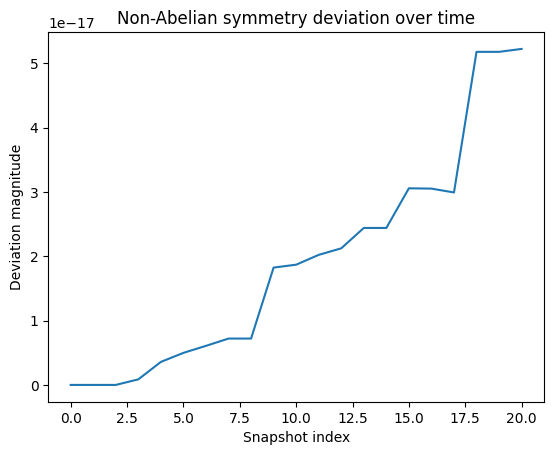

In [3]:
# Symmetry deviation
def deviation(a, b):
    return np.linalg.norm(a - b)

deviations = [deviation(history_ABC[i], history_CBA[i]) for i in range(len(history_ABC))]

plt.plot(range(len(deviations)), deviations)
plt.xlabel("Snapshot index")
plt.ylabel("Deviation magnitude")
plt.title("Non-Abelian symmetry deviation over time")
plt.show()


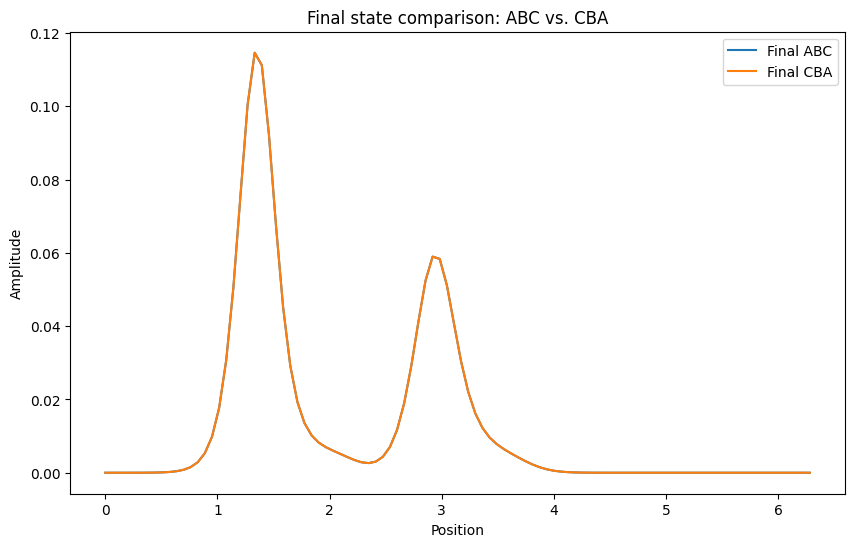

In [4]:
# Final state comparison
plt.figure(figsize=(10,6))
plt.plot(x, history_ABC[-1], label="Final ABC")
plt.plot(x, history_CBA[-1], label="Final CBA")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Final state comparison: ABC vs. CBA")
plt.legend()
plt.show()
